       id diagnosis  radius_mean  texture_mean  perimeter_mean    area_mean  \
0  100000         B    10.198616     17.956707       64.079793   326.762594   
1  100001         M    20.152831     19.093174      126.623975  1275.915814   
2  100002         M    19.129944     25.050994      120.196982  1149.680757   
3  100003         M    17.329581     21.848188      108.884966   943.465394   
4  100004         M    10.065507     22.882072       63.243446   318.288677   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0         0.095348          0.130421        0.030956             0.008875   
1         0.125227          0.179055        0.114229             0.035679   
2         0.113732          0.232850        0.199283             0.054439   
3         0.099412          0.186423        0.021243             0.007054   
4         0.098254          0.159760        0.265294             0.083472   

   ...  texture_worst  perimeter_worst   area_worst  smoothnes

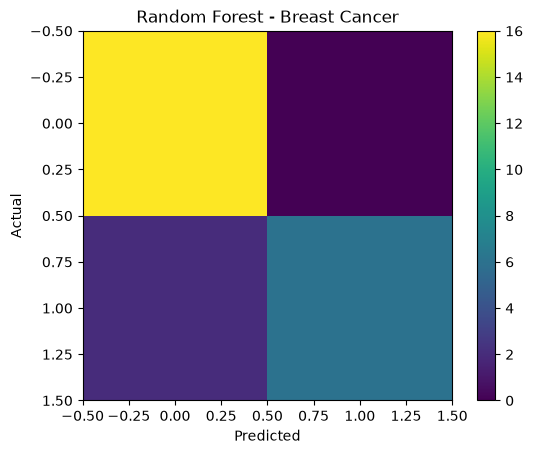

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


df = pd.read_csv("Breast_Cancer.csv")


print(df.head())


df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})


X = df.drop(["diagnosis", "id", "Unnamed: 32"], axis=1)
y = df["diagnosis"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = RandomForestClassifier(n_estimators=100, random_state=42)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)


plt.imshow(cm)
plt.title("Random Forest - Breast Cancer")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()